In [1]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df['date'] = pd.to_datetime(df['date'])

print("\n1. What is the overall average closing price of gold?")
print(df['close'].mean())


print("\n2. What was the highest gold price ever recorded (High column)?")
print(df['high'].max())


print("\n3. On which date did gold have the lowest closing price?")
print(df.loc[df['close'].idxmin()][['date', 'close']])


print("\n4. Which year had the highest average closing price?")
df['year'] = df['date'].dt.year
print(df.groupby('year')['close'].mean().idxmax())


print("\n5. What is the correlation between gold closing price and USD index?")
print(df[['close', 'usd_index']].corr())


print("\n6. How many days did gold close higher than it opened?")
print((df['close'] > df['open']).sum())


print("\n7. Top 5 dates with the highest volume traded:")
print(df.nlargest(5, 'volume')[['date', 'volume']])


print("\n8. Monthly average gold closing price for each month:")
df['month'] = df['date'].dt.month
print(df.groupby('month')['close'].mean())


print("\n9. Dates where gold price dropped more than 1% from previous day:")
df['Return'] = (df['close'] - df['Close_lag1']) / df['Close_lag1']
result = df[df['Return'] < -0.01][['date', 'close', 'Close_lag1', 'Return']]
print(result)


print("\n10. Yearly maximum 'High' gold price:")
print(df.groupby('year')['high'].max())



1. What is the overall average closing price of gold?
2225.000587201196

2. What was the highest gold price ever recorded (High column)?
4049.199951171875

3. On which date did gold have the lowest closing price?
date     2019-04-23 00:00:00
close            1269.300049
Name: 72, dtype: object

4. Which year had the highest average closing price?
2025

5. What is the correlation between gold closing price and USD index?
              close  usd_index
close      1.000000   0.457772
usd_index  0.457772   1.000000

6. How many days did gold close higher than it opened?
12708

7. Top 5 dates with the highest volume traded:
            date    volume
23395 2025-10-10  352500.0
1563  2019-11-26  346362.0
2061  2020-01-29  251274.0
750   2019-07-29  224267.0
3347  2020-07-29  209835.0

8. Monthly average gold closing price for each month:
month
1     2156.955447
2     2060.270821
3     2122.585547
4     2190.090907
5     2084.011412
6     2030.915683
7     2077.048775
8     2134.355330
9    

### KNN For Regression


===== KNN RANGE MODEL METRICS =====
Low R2:  -0.8855
High R2: -0.9113
Range Accuracy: 2.50%

===== SAMPLE PREDICTIONS (10 rows) =====
      Pred Low  Actual Close    Pred High
0  2579.794486   2565.699951  2581.201558
1  2565.699951   2565.699951  2565.699951
2  2565.699951   2565.699951  2565.699951
3  2565.699951   2565.699951  2565.699951
4  2596.525691   2565.699951  2599.603057
5  2565.699951   2565.699951  2565.699951
6  2565.699951   2565.699951  2565.699951
7  2565.699951   2565.699951  2565.699951
8  2565.699951   2565.699951  2565.699951
9  2565.699951   2565.699951  2565.699951


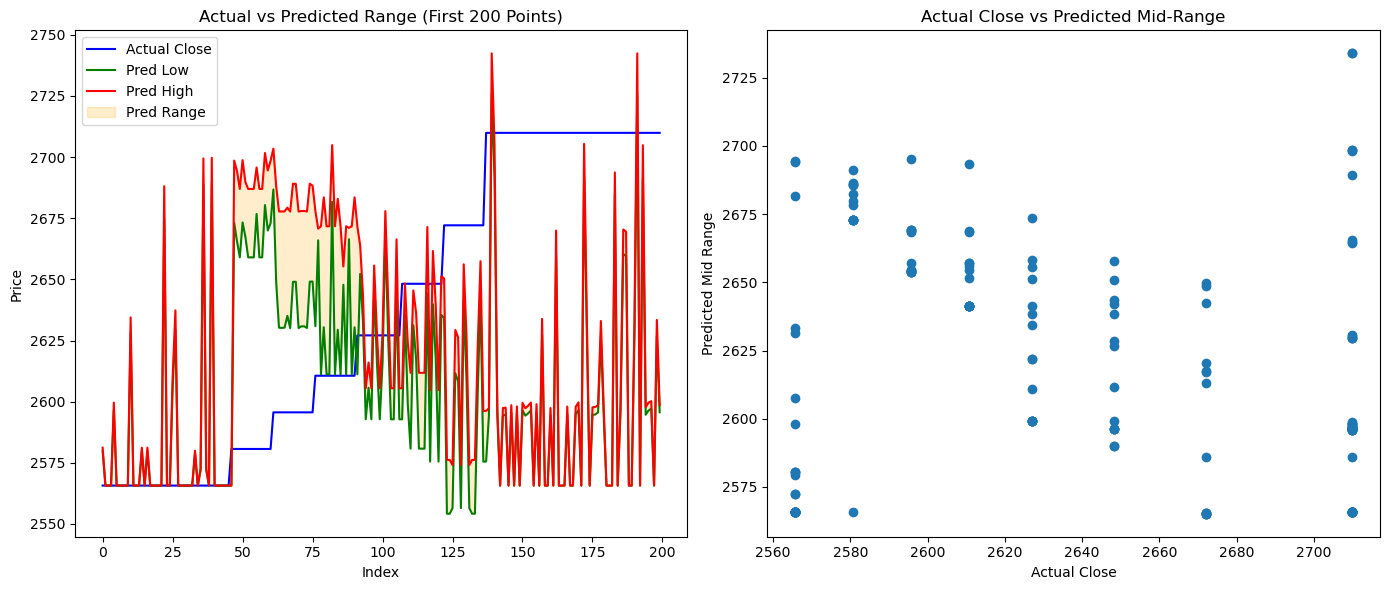

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

df = pd.read_csv("dataset.csv")

# NEXT-DAY TARGETS
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

# Drop last row (because of shift)
df = df.iloc[:-1]

# FEATURE SELECTION
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# TRAIN–TEST SPLIT (TIME SERIES)
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_low_train, y_low_test = y_low.iloc[:train_size], y_low.iloc[train_size:]
y_high_train, y_high_test = y_high.iloc[:train_size], y_high.iloc[train_size:]
y_close_test = y_close.iloc[train_size:]

# PIPELINES (SCALER + KNN)
knn_low_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5, weights="distance"))
])

knn_high_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5, weights="distance"))
])

# TRAIN
knn_low_pipe.fit(X_train, y_low_train)
knn_high_pipe.fit(X_train, y_high_train)

# PREDICT
pred_low_knn = knn_low_pipe.predict(X_test)
pred_high_knn = knn_high_pipe.predict(X_test)

# RANGE ACCURACY
correct = (
    (y_close_test >= pred_low_knn) &
    (y_close_test <= pred_high_knn)
).sum()

total = len(y_close_test)
range_acc = correct / total

print("\n===== KNN RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low_knn):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high_knn):.4f}")
print(f"Range Accuracy: {range_acc * 100:.2f}%")

# SAMPLE PREDICTIONS
sample = pd.DataFrame({
    "Pred Low": pred_low_knn[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high_knn[:10]
})

print("\n===== SAMPLE PREDICTIONS (10 rows) =====")
print(sample)

# PLOTTING
pred_mid = (pred_low_knn + pred_high_knn) / 2

N = 200
y_close_200 = y_close_test[:N]
pred_low_200 = pred_low_knn[:N]
pred_high_200 = pred_high_knn[:N]
pred_mid_200 = pred_mid[:N]

plt.figure(figsize=(14,6))

# Plot 1
plt.subplot(1,2,1)
plt.plot(y_close_200.values, label="Actual Close", color="blue")
plt.plot(pred_low_200, label="Pred Low", color="green")
plt.plot(pred_high_200, label="Pred High", color="red")
plt.fill_between(range(N), pred_low_200, pred_high_200,
                 color="orange", alpha=0.2, label="Pred Range")
plt.title("Actual vs Predicted Range (First 200 Points)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()

# Plot 2
plt.subplot(1,2,2)
plt.scatter(y_close_200, pred_mid_200)
plt.title("Actual Close vs Predicted Mid-Range")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Mid Range")

plt.tight_layout()
plt.show()


## Decision Tree (Regression)


===== DECISION TREE RANGE MODEL METRICS =====
Low R2:  -0.7178
High R2: -0.6538
Range Accuracy: 23.72%

===== SAMPLE PREDICTIONS (10 rows) =====
      Pred Low  Actual Close    Pred High
0  2565.699951   2565.699951  2565.699951
1  2565.699951   2565.699951  2565.699951
2  2565.699951   2565.699951  2565.699951
3  2565.699951   2565.699951  2565.699951
4  2565.699951   2565.699951  2565.699951
5  2565.699951   2565.699951  2565.699951
6  2565.699951   2565.699951  2565.699951
7  2565.699951   2565.699951  2565.699951
8  2565.699951   2565.699951  2565.699951
9  2565.699951   2565.699951  2565.699951


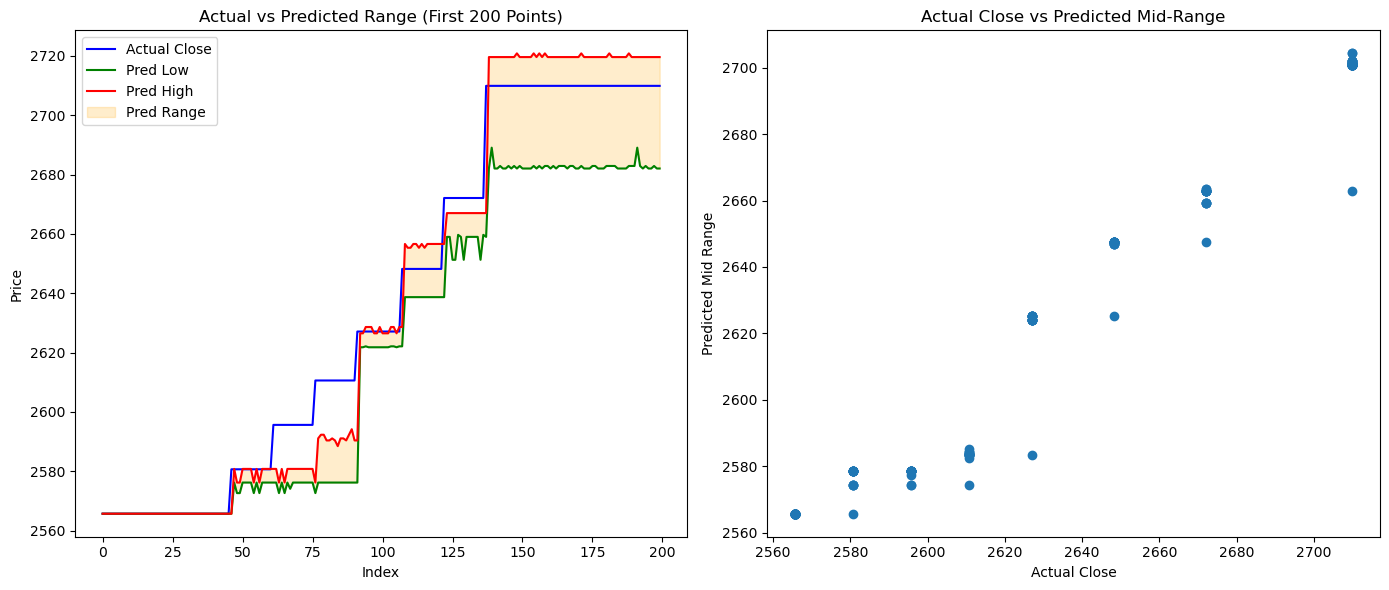

In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("dataset.csv")

# --- Create next-day targets ---
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

# Drop last row (because of shift)
df = df.iloc[:-1]

# Feature selection: all numeric except targets
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# ---- TRAIN-TEST SPLIT (time series) ----
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

# ---- Train Decision Tree models ----
tree_low = DecisionTreeRegressor(
    max_depth=10,          # you can tune this
    min_samples_leaf=5     # prevents overfitting
)

tree_high = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=5
)

tree_low.fit(X_train, y_low_train)
tree_high.fit(X_train, y_high_train)

# ---- Predictions ----
pred_low_dt= tree_low.predict(X_test)
pred_high_dt = tree_high.predict(X_test)

pred_low_dt, pred_high_dt = (
    np.minimum(pred_low_dt, pred_high_dt),
    np.maximum(pred_low_dt, pred_high_dt)
)

# ---- Range accuracy ----
correct = ((y_close_test >= pred_low_dt) & (y_close_test <= pred_high_dt)).sum()
total = len(y_close_test)

range_acc = correct / total

print("\n===== DECISION TREE RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low_dt):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high_dt):.4f}")
print(f"Range Accuracy: {range_acc * 100:.2f}%")

# ---- Show 10 sample predictions ----
sample = pd.DataFrame({
    "Pred Low": pred_low_dt[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high_dt[:10]
})

print("\n===== SAMPLE PREDICTIONS (10 rows) =====")
print(sample)


# Midpoint of predicted range
pred_mid = (pred_low_dt + pred_high_dt) / 2

# Plot only first 200 for readability
N = 200
y_close_200 = y_close_test[:N]
pred_low_200 = pred_low_dt[:N]
pred_high_200 = pred_high_dt[:N]
pred_mid_200 = pred_mid[:N]

plt.figure(figsize=(14,6))

# --- Plot 1: Actual close + predicted low/high (range band) ---
plt.subplot(1,2,1)
plt.plot(y_close_200.values, label="Actual Close", color="blue")
plt.plot(pred_low_200, label="Pred Low", color="green")
plt.plot(pred_high_200, label="Pred High", color="red")
plt.fill_between(range(N), pred_low_200, pred_high_200, color="orange", alpha=0.2, label="Pred Range")

plt.title("Actual vs Predicted Range (First 200 Points)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()

# --- Plot 2: Scatter of actual close vs midpoint of predicted range ---
plt.subplot(1,2,2)
plt.scatter(y_close_200, pred_mid_200)
plt.title("Actual Close vs Predicted Mid-Range")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Mid Range")

plt.tight_layout()
plt.show()


## SVM


===== SVM RANGE MODEL METRICS =====
Low R2:  -3.7026
High R2: -3.6289
Range Accuracy: 1.97%

SAMPLE PREDICTIONS (10 rows)
      Pred Low  Actual Close    Pred High
0  2563.444642   2565.699951  2568.420277
1  2565.972343   2565.699951  2567.139363
2  2565.744127   2565.699951  2566.498833
3  2561.122480   2565.699951  2564.156393
4  2565.525488   2565.699951  2565.653867
5  2559.836861   2565.699951  2562.706501
6  2565.806706   2565.699951  2566.527438
7  2564.331678   2565.699951  2564.829169
8  2562.852549   2565.699951  2563.973066
9  2565.576468   2565.699951  2566.279315


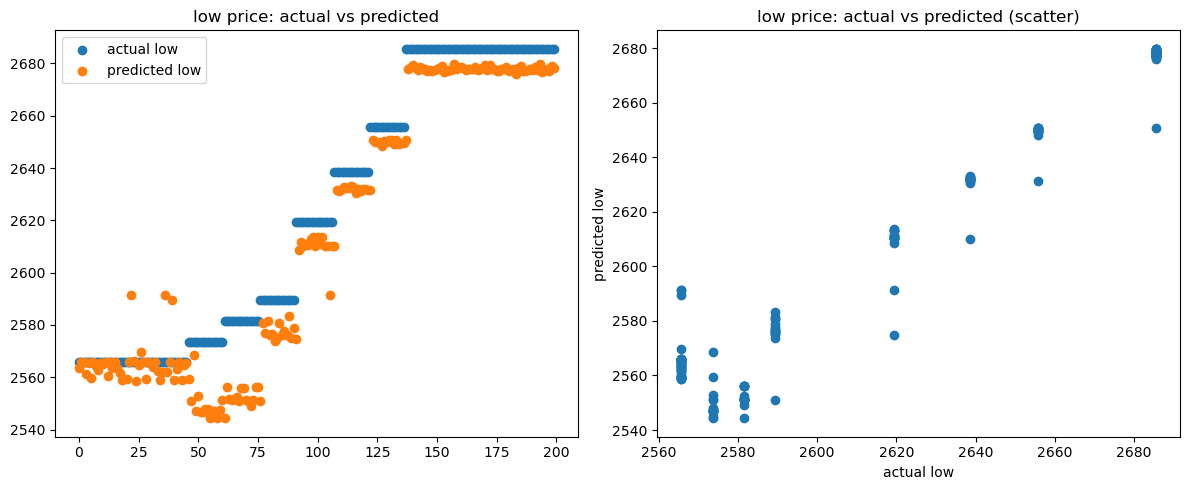

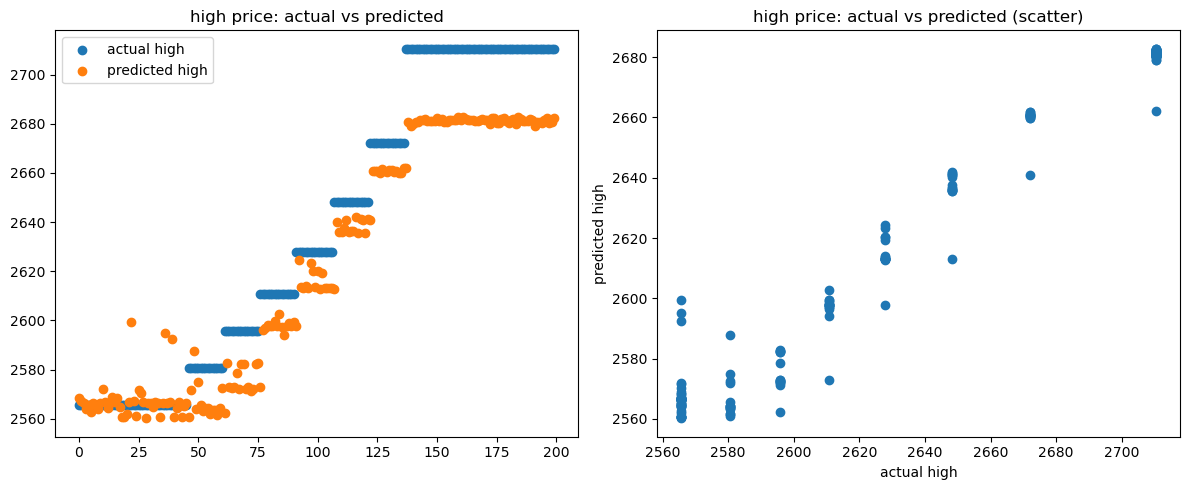

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# load raw data
df = pd.read_csv("dataset.csv")

# next-day targets
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)
df = df.iloc[:-1]

# features
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next","high_next","close_next","close"]:
    if col in features: features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# train-test split
train_size = int(len(df)*0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_low_train, y_low_test = y_low.iloc[:train_size], y_low.iloc[train_size:]
y_high_train, y_high_test = y_high.iloc[:train_size], y_high.iloc[train_size:]
y_close_test = y_close.iloc[train_size:]

# pipelines
svm_low_pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVR(kernel="rbf", C=100, epsilon=0.01))])
svm_high_pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVR(kernel="rbf", C=100, epsilon=0.01))])

# train
svm_low_pipe.fit(X_train, y_low_train)
svm_high_pipe.fit(X_train, y_high_train)

# predict
pred_low_svm = svm_low_pipe.predict(X_test)
pred_high_svm = svm_high_pipe.predict(X_test)

# ensure low <= high
pred_low_svm, pred_high_svm = np.minimum(pred_low_svm, pred_high_svm), np.maximum(pred_low_svm, pred_high_svm)

# range accuracy
correct = ((y_close_test >= pred_low_svm) & (y_close_test <= pred_high_svm)).sum()
range_acc = correct / len(y_close_test)

# metrics
print("\n===== SVM RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low_svm):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high_svm):.4f}")
print(f"Range Accuracy: {range_acc*100:.2f}%")

# sample predictions
sample = pd.DataFrame({"Pred Low": pred_low_svm[:10], "Actual Close": y_close_test[:10].values, "Pred High": pred_high_svm[:10]})
print("\nSAMPLE PREDICTIONS (10 rows)")
print(sample)

# plotting low
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(range(len(y_low_test[:200])), y_low_test[:200], label="actual low")
plt.scatter(range(len(pred_low_svm[:200])), pred_low_svm[:200], label="predicted low")
plt.title("low price: actual vs predicted")
plt.legend()
plt.subplot(1,2,2)
plt.scatter(y_low_test[:200], pred_low_svm[:200])
plt.title("low price: actual vs predicted (scatter)")
plt.xlabel("actual low"); plt.ylabel("predicted low")
plt.tight_layout()
plt.show()

# plotting high
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(range(len(y_high_test[:200])), y_high_test[:200], label="actual high")
plt.scatter(range(len(pred_high_svm[:200])), pred_high_svm[:200], label="predicted high")
plt.title("high price: actual vs predicted")
plt.legend()
plt.subplot(1,2,2)
plt.scatter(y_high_test[:200], pred_high_svm[:200])
plt.title("high price: actual vs predicted (scatter)")
plt.xlabel("actual high"); plt.ylabel("predicted high")
plt.tight_layout()
plt.show()


## Random Forest (Ensemble)


===== RANGE MODEL METRICS =====
Low R2:  -0.6579
High R2: -0.7009
Range Accuracy: 21.18%

SAMPLE PREDICTIONS (10 rows) 
      Pred Low  Actual Close    Pred High
0  2565.279383   2565.699951  2565.336080
1  2565.279383   2565.699951  2566.561079
2  2565.279383   2565.699951  2566.044810
3  2565.279383   2565.699951  2565.336080
4  2565.279383   2565.699951  2565.983356
5  2565.279383   2565.699951  2565.336080
6  2565.279383   2565.699951  2566.107740
7  2565.279383   2565.699951  2565.336080
8  2565.279383   2565.699951  2565.336080
9  2565.279383   2565.699951  2565.336080


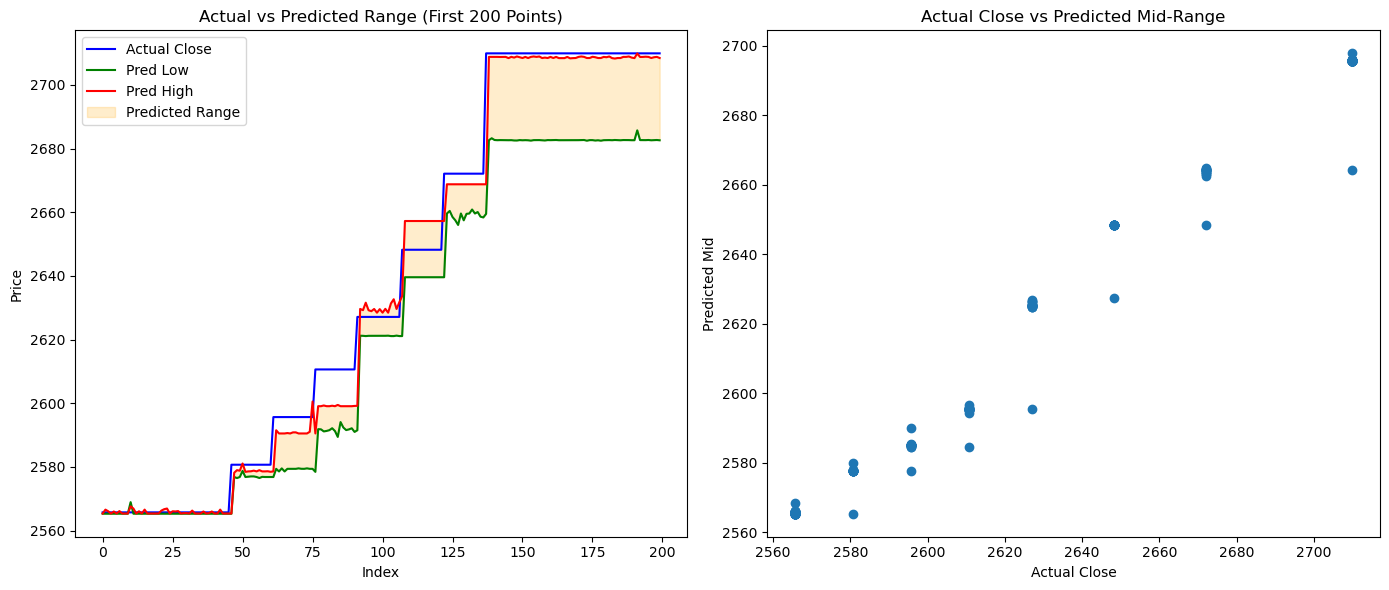

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("dataset.csv")

# next-day targets
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

# Drop last row (because of shift)
df = df.iloc[:-1]

# Feature selection
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# TRAIN-TEST SPLIT (time series)
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

# Train models
low_model = RandomForestRegressor(n_estimators=300, max_depth=8)
high_model = RandomForestRegressor(n_estimators=300, max_depth=8)

low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

# Predictions
pred_low_rf = low_model.predict(X_test)
pred_high_rf = high_model.predict(X_test)

# Range accuracy
correct = ((y_close_test >= pred_low_rf) & (y_close_test <= pred_high_rf)).sum()
total = len(y_close_test)
range_acc = correct / total

print("\n===== RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low_rf):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high_rf):.4f}")
print(f"Range Accuracy: {range_acc * 100:.2f}%")

# 10 sample predictions
sample = pd.DataFrame({
    "Pred Low": pred_low_rf[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high_rf[:10]
})

print("\nSAMPLE PREDICTIONS (10 rows) ")
print(sample)

# midpoint of predicted range
pred_mid = (pred_low_rf + pred_high_rf) / 2

N = 200  # first 200 points

y_close_200 = y_close_test[:N]
pred_low_200 = pred_low_rf[:N]
pred_high_200 = pred_high_rf[:N]
pred_mid_200 = pred_mid[:N]

plt.figure(figsize=(14,6))

# --- Plot 1: actual vs predicted range
plt.subplot(1,2,1)
plt.plot(y_close_200.values, label="Actual Close", color="blue")
plt.plot(pred_low_200, label="Pred Low", color="green")
plt.plot(pred_high_200, label="Pred High", color="red")
plt.fill_between(range(N), pred_low_200, pred_high_200, alpha=0.2, color="orange", label="Predicted Range")

plt.title("Actual vs Predicted Range (First 200 Points)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()

# --- Plot 2: scatter actual vs predicted mid-range
plt.subplot(1,2,2)
plt.scatter(y_close_200, pred_mid_200)
plt.title("Actual Close vs Predicted Mid-Range")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Mid")

plt.tight_layout()
plt.show()


## XGBoost (Ensemble)


===== XGBOOST RANGE MODEL METRICS =====
Low R2:  -0.7002
High R2: -0.7421
Range Accuracy: 14.58%

SAMPLE PREDICTIONS (10 rows)
      Pred Low  Actual Close    Pred High
0  2564.868164   2565.699951  2566.830566
1  2553.528809   2565.699951  2546.048584
2  2564.989502   2565.699951  2566.296875
3  2565.122559   2565.699951  2566.722656
4  2564.971924   2565.699951  2566.541260
5  2564.896729   2565.699951  2566.674561
6  2565.056396   2565.699951  2566.516602
7  2565.314697   2565.699951  2566.336426
8  2564.449951   2565.699951  2564.753906
9  2565.054688   2565.699951  2566.266113


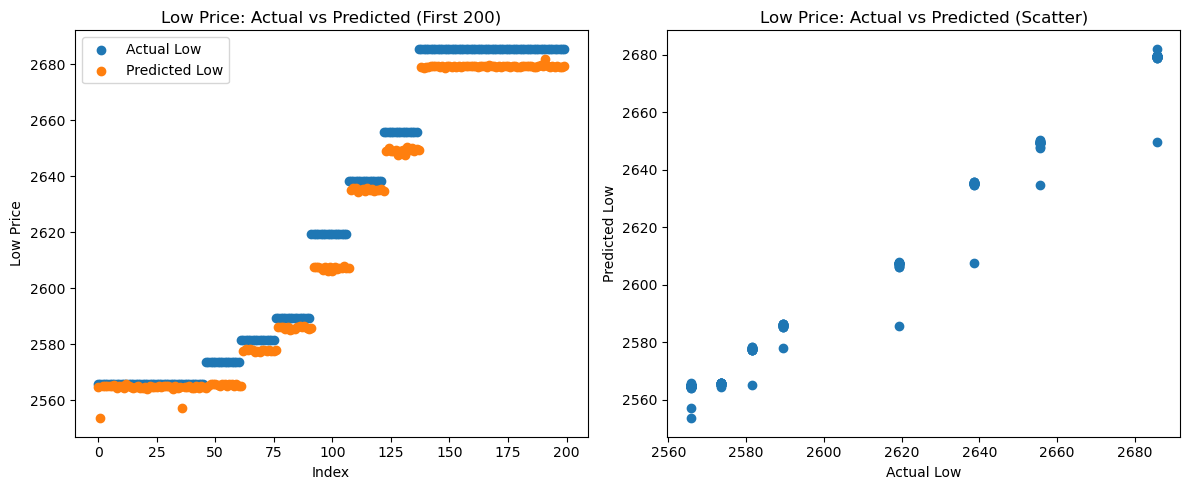

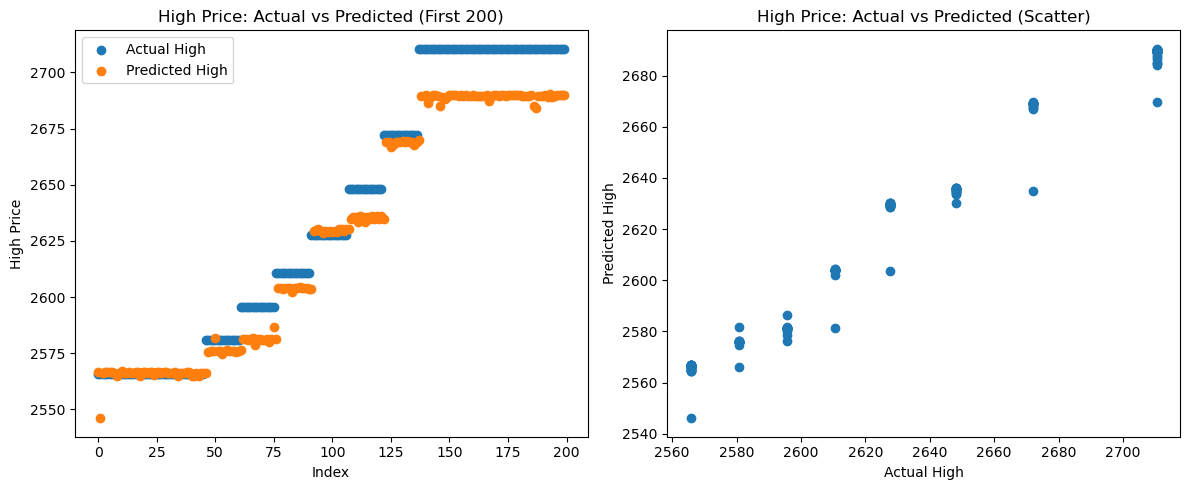

In [6]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("dataset.csv")

df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

df = df.iloc[:-1]

# FEATURES
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# TIME SPLIT
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

# TRAIN XGBOOST MODELS
low_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

high_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

# PREDICTIONS
pred_low_xgb = low_model.predict(X_test)
pred_high_xgb = high_model.predict(X_test)

# RANGE ACCURACY
correct = ((y_close_test >= pred_low_xgb) & (y_close_test <= pred_high_xgb)).sum()
total = len(y_close_test)
range_acc = correct / total

print("\n===== XGBOOST RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low_xgb):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high_xgb):.4f}")
print(f"Range Accuracy: {range_acc* 100:.2f}%")

# SAMPLE
sample = pd.DataFrame({
    "Pred Low": pred_low_xgb[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high_xgb[:10]
})
print("\nSAMPLE PREDICTIONS (10 rows)")
print(sample)


# Plot: Actual vs Predicted LOW
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(range(len(y_low_test[:200])), y_low_test[:200], label="Actual Low")
plt.scatter(range(len(pred_low_xgb[:200])), pred_low_xgb[:200], label="Predicted Low")
plt.title("Low Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("Low Price")
plt.legend()

# Scatter plot actual vs predicted low
plt.subplot(1,2,2)
plt.scatter(y_low_test[:200], pred_low_xgb[:200])
plt.title("Low Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual Low")
plt.ylabel("Predicted Low")

plt.tight_layout()
plt.show()


# Plot: Actual vs Predicted HIGH
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(range(len(y_high_test[:200])), y_high_test[:200], label="Actual High")
plt.scatter(range(len(pred_high_xgb[:200])), pred_high_xgb[:200], label="Predicted High")
plt.title("High Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("High Price")
plt.legend()

# Scatter plot actual vs predicted high
plt.subplot(1,2,2)
plt.scatter(y_high_test[:200], pred_high_xgb[:200])
plt.title("High Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual High")
plt.ylabel("Predicted High")

plt.tight_layout()
plt.show()


## Adaboost (Ensemble)


===== ADA BOOST RANGE MODEL METRICS =====
Low R2:  -0.7356
High R2: -0.7350
Range Accuracy: 19.23%

SAMPLE PREDICTIONS (10 rows) 
      Pred Low  Actual Close  Pred High
0  2565.831677   2565.699951   2575.264
1  2565.831677   2565.699951   2575.264
2  2565.831677   2565.699951   2575.264
3  2565.831677   2565.699951   2575.264
4  2565.831677   2565.699951   2575.264
5  2565.831677   2565.699951   2575.264
6  2565.831677   2565.699951   2575.264
7  2565.831677   2565.699951   2575.264
8  2565.831677   2565.699951   2575.264
9  2565.831677   2565.699951   2575.264


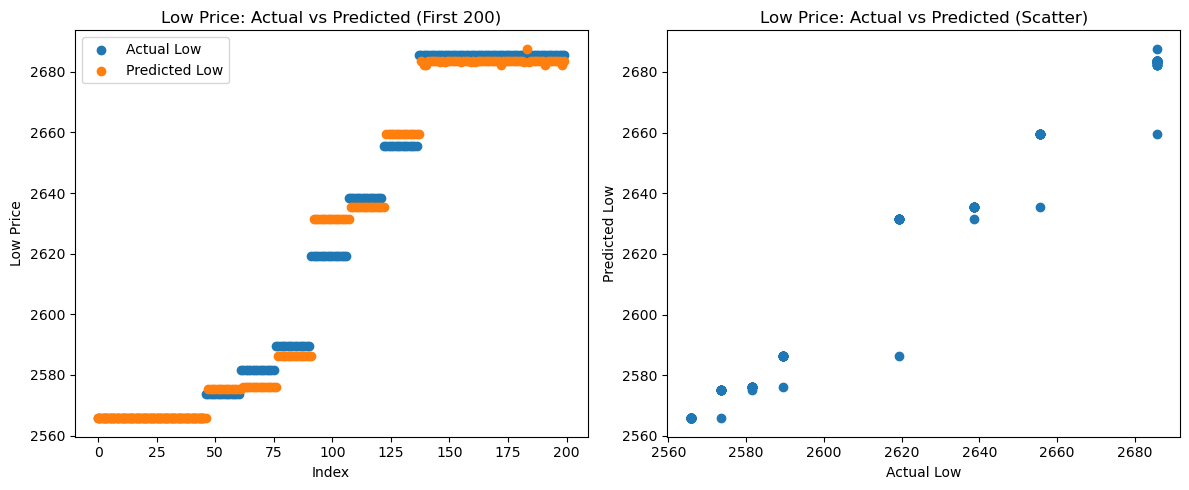

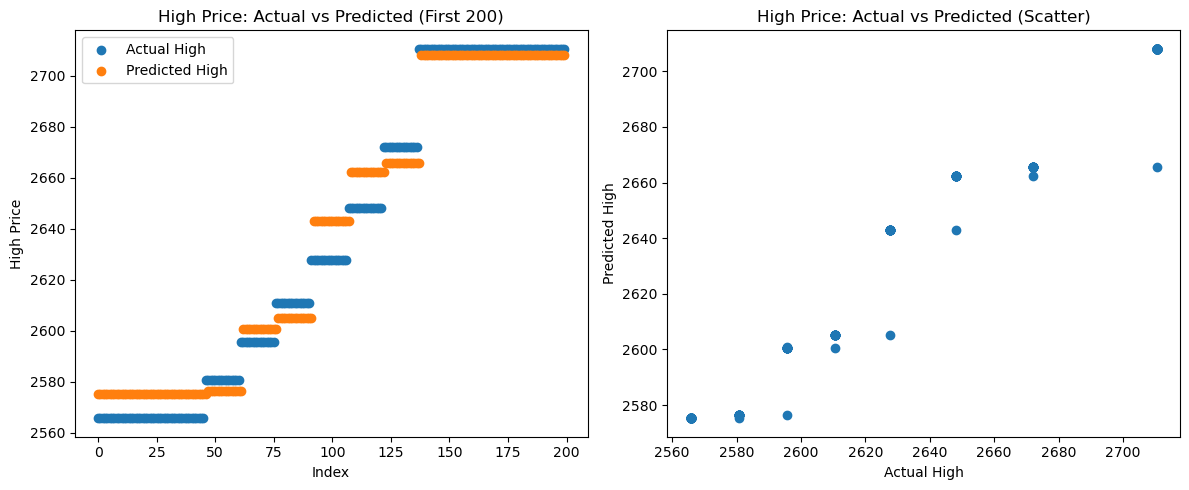

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

df = pd.read_csv("dataset.csv")

# next-day targets
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)

df = df.iloc[:-1]

# FEATURES
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next", "high_next", "close_next", "close"]:
    if col in features:
        features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# TIME SPLIT
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

# ADA BOOST MODELS
# Weak learner (base estimator)
base = DecisionTreeRegressor(max_depth=5)

low_model = AdaBoostRegressor(
    estimator=base,
    n_estimators=300,
    learning_rate=0.05,
    loss='linear'
)

high_model = AdaBoostRegressor(
    estimator=base,
    n_estimators=300,
    learning_rate=0.05,
    loss='linear'
)

# Train
low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

# PREDICTIONS
pred_low_ada= low_model.predict(X_test)
pred_high_ada = high_model.predict(X_test)

# RANGE ACCURACY
correct = ((y_close_test >= pred_low_ada) & (y_close_test <= pred_high_ada)).sum()
range_acc = correct / len(y_close_test)


print("\n===== ADA BOOST RANGE MODEL METRICS =====")
print(f"Low R2:  {r2_score(y_low_test, pred_low_ada):.4f}")
print(f"High R2: {r2_score(y_high_test, pred_high_ada):.4f}")
print(f"Range Accuracy: {range_acc * 100:.2f}%")

# SAMPLE OUTPUT
sample = pd.DataFrame({
    "Pred Low": pred_low_ada[:10],
    "Actual Close": y_close_test[:10].values,
    "Pred High": pred_high_ada[:10]
})
print("\nSAMPLE PREDICTIONS (10 rows) ")
print(sample)


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(range(len(y_low_test[:200])), y_low_test[:200], label="Actual Low")
plt.scatter(range(len(pred_low_ada[:200])), pred_low_ada[:200], label="Predicted Low")
plt.title("Low Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("Low Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_low_test[:200], pred_low_ada[:200])
plt.title("Low Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual Low")
plt.ylabel("Predicted Low")

plt.tight_layout()
plt.show()


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(range(len(y_high_test[:200])), y_high_test[:200], label="Actual High")
plt.scatter(range(len(pred_high_ada[:200])), pred_high_ada[:200], label="Predicted High")
plt.title("High Price: Actual vs Predicted (First 200)")
plt.xlabel("Index")
plt.ylabel("High Price")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_high_test[:200], pred_high_ada[:200])
plt.title("High Price: Actual vs Predicted (Scatter)")
plt.xlabel("Actual High")
plt.ylabel("Predicted High")

plt.tight_layout()
plt.show()


## Linear Regression


linear regression range model metrics
low r2:  0.9998
high r2: 0.9999
range accuracy: 94.64%

sample predictions (10 rows)
      pred low  actual close    pred high
0  2565.498757   2565.699951  2566.153608
1  2565.344672   2565.699951  2565.973423
2  2565.325831   2565.699951  2565.963601
3  2565.429352   2565.699951  2566.095818
4  2565.350889   2565.699951  2566.018405
5  2565.435125   2565.699951  2566.090074
6  2565.321664   2565.699951  2565.960525
7  2565.369732   2565.699951  2566.004094
8  2565.380495   2565.699951  2566.011498
9  2565.381189   2565.699951  2566.007365


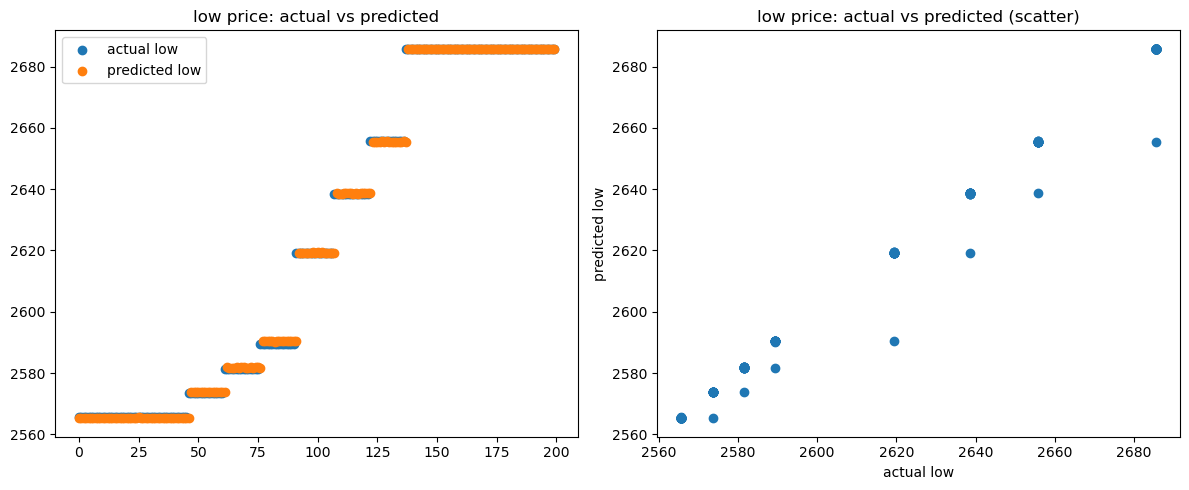

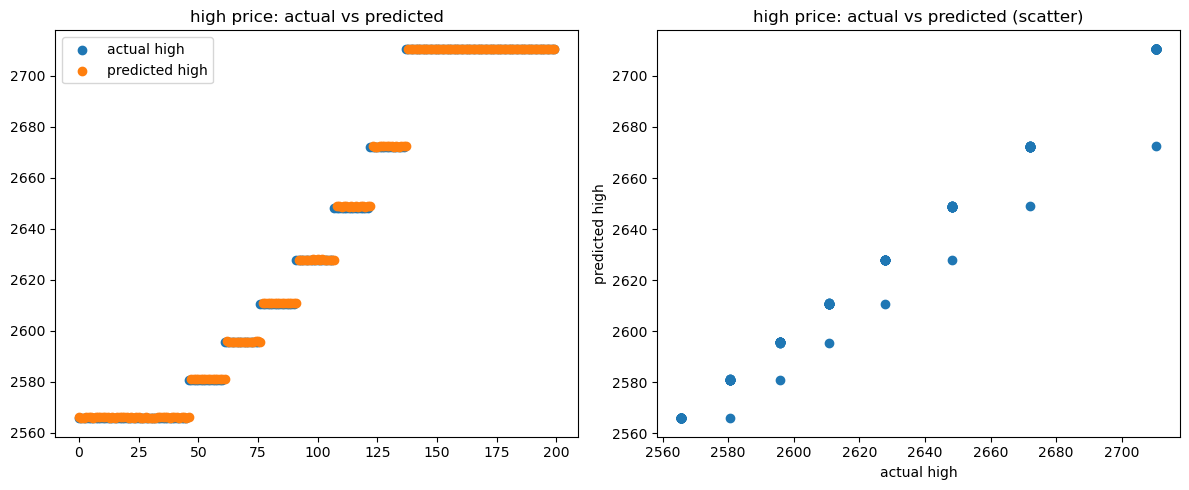

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import numpy as np

df = pd.read_csv("dataset.csv")

df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)
df = df.iloc[:-1]

features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next","high_next","close_next","close"]:
    if col in features: features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

train_size = int(len(df)*0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_low_train, y_low_test = y_low.iloc[:train_size], y_low.iloc[train_size:]
y_high_train, y_high_test = y_high.iloc[:train_size], y_high.iloc[train_size:]
y_close_test = y_close.iloc[train_size:]

low_model = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
high_model = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])

low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

pred_low_lr = low_model.predict(X_test)
pred_high_lr = high_model.predict(X_test)

pred_low_lr, pred_high_lr = np.minimum(pred_low_lr, pred_high_lr), np.maximum(pred_low_lr, pred_high_lr)

correct = ((y_close_test >= pred_low_lr) & (y_close_test <= pred_high_lr)).sum()
range_acc = correct / len(y_close_test)

print("\nlinear regression range model metrics")
print(f"low r2:  {r2_score(y_low_test, pred_low_lr):.4f}")
print(f"high r2: {r2_score(y_high_test, pred_high_lr):.4f}")
print(f"range accuracy: {range_acc*100:.2f}%")

sample = pd.DataFrame({"pred low": pred_low_lr[:10], "actual close": y_close_test[:10].values, "pred high": pred_high_lr[:10]})
print("\nsample predictions (10 rows)")
print(sample)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(range(len(y_low_test[:200])), y_low_test[:200], label="actual low")
plt.scatter(range(len(pred_low_lr[:200])), pred_low_lr[:200], label="predicted low")
plt.title("low price: actual vs predicted")
plt.legend()
plt.subplot(1,2,2)
plt.scatter(y_low_test[:200], pred_low_lr[:200])
plt.title("low price: actual vs predicted (scatter)")
plt.xlabel("actual low"); plt.ylabel("predicted low")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(range(len(y_high_test[:200])), y_high_test[:200], label="actual high")
plt.scatter(range(len(pred_high_lr[:200])), pred_high_lr[:200], label="predicted high")
plt.title("high price: actual vs predicted")
plt.legend()
plt.subplot(1,2,2)
plt.scatter(y_high_test[:200], pred_high_lr[:200])
plt.title("high price: actual vs predicted (scatter)")
plt.xlabel("actual high"); plt.ylabel("predicted high")
plt.tight_layout()
plt.show()

### Linear Regression Verification (wihout lag and rolling features)

In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# load dataset
df = pd.read_csv("dataset.csv")

# create next-day targets
df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)
df = df.iloc[:-1]

# remove lag and rolling features
lag_rolling_cols = [col for col in df.columns if "lag" in col or "roll" in col]
features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["low_next","high_next","close_next","close"] + lag_rolling_cols:
    if col in features: features.remove(col)

X = df[features]
y_low = df["low_next"]
y_high = df["high_next"]
y_close = df["close_next"]

# train-test split
train_size = int(len(df)*0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_low_train, y_low_test = y_low.iloc[:train_size], y_low.iloc[train_size:]
y_high_train, y_high_test = y_high.iloc[:train_size], y_high.iloc[train_size:]
y_close_test = y_close.iloc[train_size:]

# linear regression with scaling
low_model = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
high_model = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])

low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

pred_low_lr = low_model.predict(X_test)
pred_high_lr = high_model.predict(X_test)

pred_low_lr, pred_high_lr = np.minimum(pred_low_lr, pred_high_lr), np.maximum(pred_low_lr, pred_high_lr)

correct = ((y_close_test >= pred_low_lr) & (y_close_test <= pred_high_lr)).sum()
range_acc = correct / len(y_close_test)

print("\nlinear regression without lag/rolling features")
print(f"low r2:  {r2_score(y_low_test, pred_low_lr):.4f}")
print(f"high r2: {r2_score(y_high_test, pred_high_lr):.4f}")
print(f"range accuracy: {range_acc*100:.2f}%")

#even without lag/rolling features, linear regression still performs extremely well, 
#this confirms that short-term price movements are highly autocorrelated


linear regression without lag/rolling features
low r2:  0.9998
high r2: 0.9999
range accuracy: 95.47%


## K Means Clustering

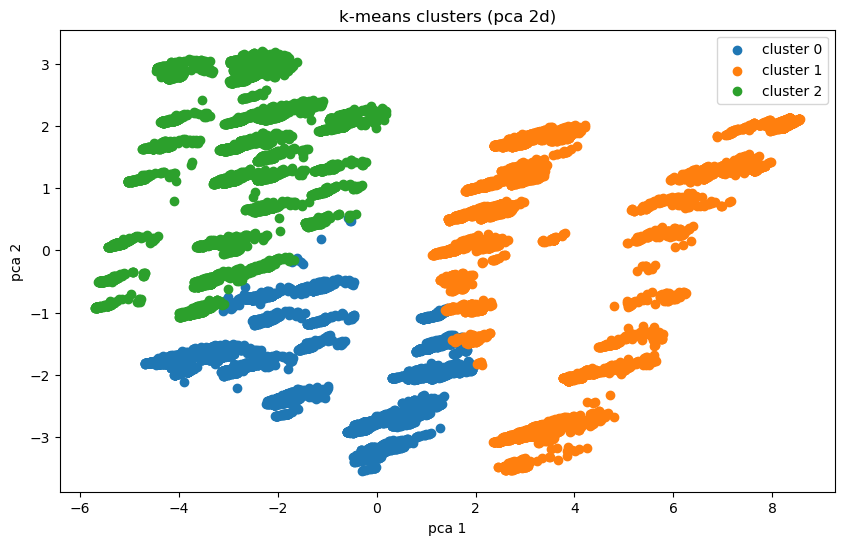


cluster summary
                 low                                               high  \
                mean         std          min          max         mean   
cluster                                                                   
0        1995.697277  231.466645  1452.099976  2400.033285  2018.626200   
1        2913.986053  535.162412  2283.800049  3987.199951  2946.932262   
2        1731.778885  190.837631  1266.000000  2066.500000  1747.930480   

                                                     close              \
                std          min          max         mean         std   
cluster                                                                  
0        234.502960  1484.000000  2429.133382  2006.315069  233.562799   
1        545.369111  2309.300049  4049.199951  2933.387400  545.514984   
2        192.734606  1269.800049  2130.199951  1739.923065  191.899876   

                                   
                 min          max  
cluster        

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

df = pd.read_csv("dataset.csv")  # use raw dataset

numeric_features = df.select_dtypes(include=['float64','int64']).columns.tolist()
features_to_use = [f for f in numeric_features if f not in ['close','low','high']]

X = df[features_to_use].values

# pipeline for scaling + kmeans
k = 3
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=k, random_state=42))
])

df['cluster'] = pipeline.fit_predict(X)

# pca for 2d viz
pca = PCA(n_components=2, random_state=42)
X_scaled = pipeline.named_steps['scaler'].transform(X)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
for cluster in range(k):
    plt.scatter(
        X_pca[df['cluster']==cluster,0],
        X_pca[df['cluster']==cluster,1],
        label=f"cluster {cluster}"
    )
plt.title("k-means clusters (pca 2d)")
plt.xlabel("pca 1")
plt.ylabel("pca 2")
plt.legend()
plt.show()

cluster_summary = df.groupby('cluster')[['low','high','close']].agg(['mean','std','min','max'])
print("\ncluster summary")
print(cluster_summary)

for cluster in range(k):
    print(f"\nsample days in cluster {cluster}")
    print(df[df['cluster']==cluster][['close','low','high']].head(5))


## Neural Network Perceptron

C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
low r2:  0.3504
high r2: 0.3339
range accuracy: 8.83%


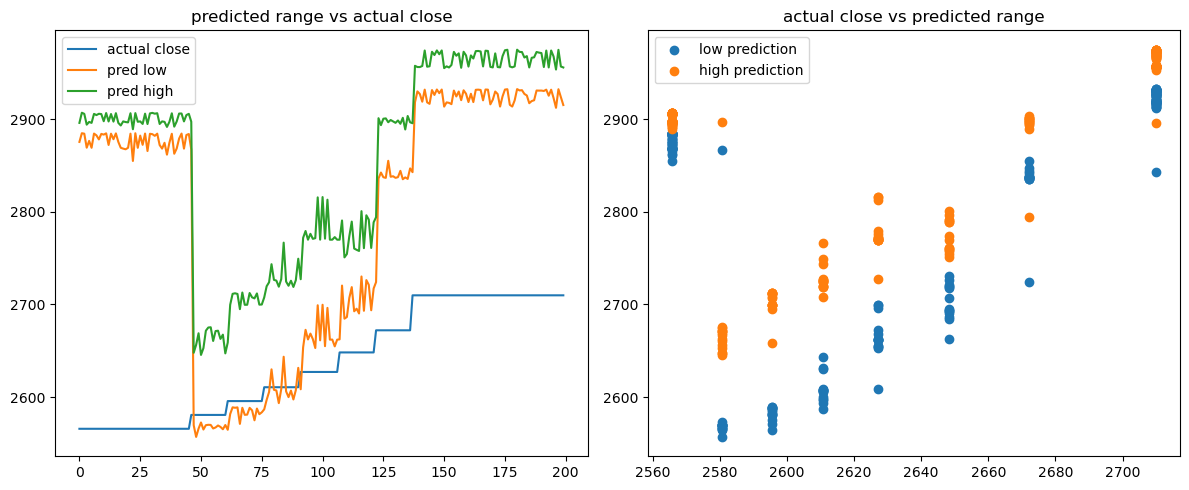

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

df = pd.read_csv("dataset.csv")  # raw dataset

df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)
df = df.iloc[:-1]

features = df.select_dtypes(include=['float64','int64']).columns.tolist()
for col in ["low_next","high_next","close_next","close"]:
    if col in features: features.remove(col)

X = df[features].values
y_low = df["low_next"].values
y_high = df["high_next"].values
y_close = df["close_next"].values

# scale and apply pca
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

train_size = int(len(X_pca) * 0.8)
X_train, X_test = X_pca[:train_size], X_pca[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

def build_mlp(input_dim):
    model = Sequential([
        Dense(64, input_dim=input_dim, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

low_model = build_mlp(X_train.shape[1])
high_model = build_mlp(X_train.shape[1])

low_model.fit(X_train, y_low_train, validation_split=0.1, epochs=50, batch_size=32, verbose=0)
high_model.fit(X_train, y_high_train, validation_split=0.1, epochs=50, batch_size=32, verbose=0)

pred_low_nn = low_model.predict(X_test).flatten()
pred_high_nn = high_model.predict(X_test).flatten()

pred_low_nn, pred_high_nn = np.minimum(pred_low_nn, pred_high_nn), np.maximum(pred_low_nn, pred_high_nn)

correct = ((y_close_test >= pred_low_nn) & (y_close_test <= pred_high_nn)).sum()
range_acc = correct / len(y_close_test)

print(f"low r2:  {r2_score(y_low_test, pred_low_nn):.4f}")
print(f"high r2: {r2_score(y_high_test, pred_high_nn):.4f}")
print(f"range accuracy: {range_acc*100:.2f}%")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(len(y_close_test[:200])), y_close_test[:200], label="actual close")
plt.plot(range(len(pred_low_nn[:200])), pred_low_nn[:200], label="pred low")
plt.plot(range(len(pred_high_nn[:200])), pred_high_nn[:200], label="pred high")
plt.title("predicted range vs actual close")
plt.legend()
plt.subplot(1,2,2)
plt.scatter(y_close_test[:200], pred_low_nn[:200], label="low prediction")
plt.scatter(y_close_test[:200], pred_high_nn[:200], label="high prediction")
plt.title("actual close vs predicted range")
plt.legend()
plt.tight_layout()
plt.show()


## Gradient Descent

low r2:  0.9548
high r2: 0.9491
range accuracy: 16.33%


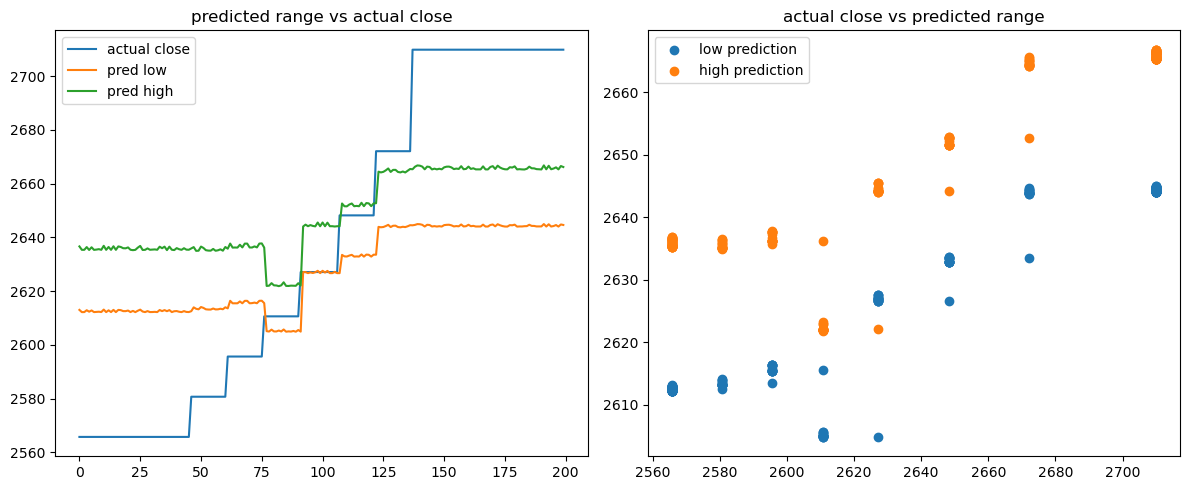

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

df = pd.read_csv("dataset.csv")  # raw dataset

df["low_next"] = df["low"].shift(-1)
df["high_next"] = df["high"].shift(-1)
df["close_next"] = df["close"].shift(-1)
df = df.iloc[:-1]

features = df.select_dtypes(include=['float64','int64']).columns.tolist()
for col in ["low_next","high_next","close_next","close"]:
    if col in features: features.remove(col)

X = df[features].values
y_low = df["low_next"].values
y_high = df["high_next"].values
y_close = df["close_next"].values

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# pca
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

train_size = int(len(X_pca) * 0.8)
X_train, X_test = X_pca[:train_size], X_pca[train_size:]
y_low_train, y_low_test = y_low[:train_size], y_low[train_size:]
y_high_train, y_high_test = y_high[:train_size], y_high[train_size:]
y_close_test = y_close[train_size:]

class LinearRegressorGD:
    def __init__(self, lr=0.001, epochs=5000):
        self.lr = lr
        self.epochs = epochs
    def fit(self, X, y):
        self.X = np.c_[np.ones(X.shape[0]), X]
        self.y = y.reshape(-1,1)
        self.theta = np.zeros((self.X.shape[1],1))
        for _ in range(self.epochs):
            error = self.X @ self.theta - self.y
            gradient = (self.X.T @ error) / len(self.y)
            self.theta -= self.lr * gradient
    def predict(self, X):
        X_ = np.c_[np.ones(X.shape[0]), X]
        return (X_ @ self.theta).flatten()

low_model = LinearRegressorGD(lr=0.01, epochs=5000)
high_model = LinearRegressorGD(lr=0.01, epochs=5000)

low_model.fit(X_train, y_low_train)
high_model.fit(X_train, y_high_train)

pred_low_gd = low_model.predict(X_test)
pred_high_gd = high_model.predict(X_test)

pred_low_gd, pred_high_gd = np.minimum(pred_low_gd, pred_high_gd), np.maximum(pred_low_gd, pred_high_gd)

correct = ((y_close_test >= pred_low_gd) & (y_close_test <= pred_high_gd)).sum()
range_acc = correct / len(y_close_test)

print(f"low r2:  {r2_score(y_low_test, pred_low_gd):.4f}")
print(f"high r2: {r2_score(y_high_test, pred_high_gd):.4f}")
print(f"range accuracy: {range_acc*100:.2f}%")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(len(y_close_test[:200])), y_close_test[:200], label="actual close")
plt.plot(range(len(pred_low_gd[:200])), pred_low_gd[:200], label="pred low")
plt.plot(range(len(pred_high_gd[:200])), pred_high_gd[:200], label="pred high")
plt.title("predicted range vs actual close")
plt.legend()
plt.subplot(1,2,2)
plt.scatter(y_close_test[:200], pred_low_gd[:200], label="low prediction")
plt.scatter(y_close_test[:200], pred_high_gd[:200], label="high prediction")
plt.title("actual close vs predicted range")
plt.legend()
plt.tight_layout()
plt.show()


### Comparisons


===== model comparison =====
               model    low_r2   high_r2       mse_low      mse_high  \
6  Linear Regression  0.999829  0.999853  4.821234e+01  4.312894e+01   
2      Decision Tree -0.717839 -0.653806  4.851013e+05  4.837324e+05   
0      Random Forest -0.657893 -0.700910  4.681732e+05  4.975101e+05   
5           AdaBoost -0.735632 -0.735015  4.901260e+05  5.074859e+05   
8   Gradient Descent  0.954841  0.949099  1.275246e+04  1.488825e+04   
4            XGBoost -0.700247 -0.742129  4.801335e+05  5.095666e+05   
7         Neural Net  0.350362  0.333862  1.834514e+05  1.948431e+05   
1                KNN -0.885519 -0.911336  5.324525e+05  5.590590e+05   
3                SVM -3.702555 -3.628949  1.327957e+06  1.353951e+06   

   range_acc  
6  94.635606  
2  23.723018  
0  21.179739  
5  19.234879  
8  16.328275  
4  14.575764  
7   8.826672  
1   2.500534  
3   1.966232  


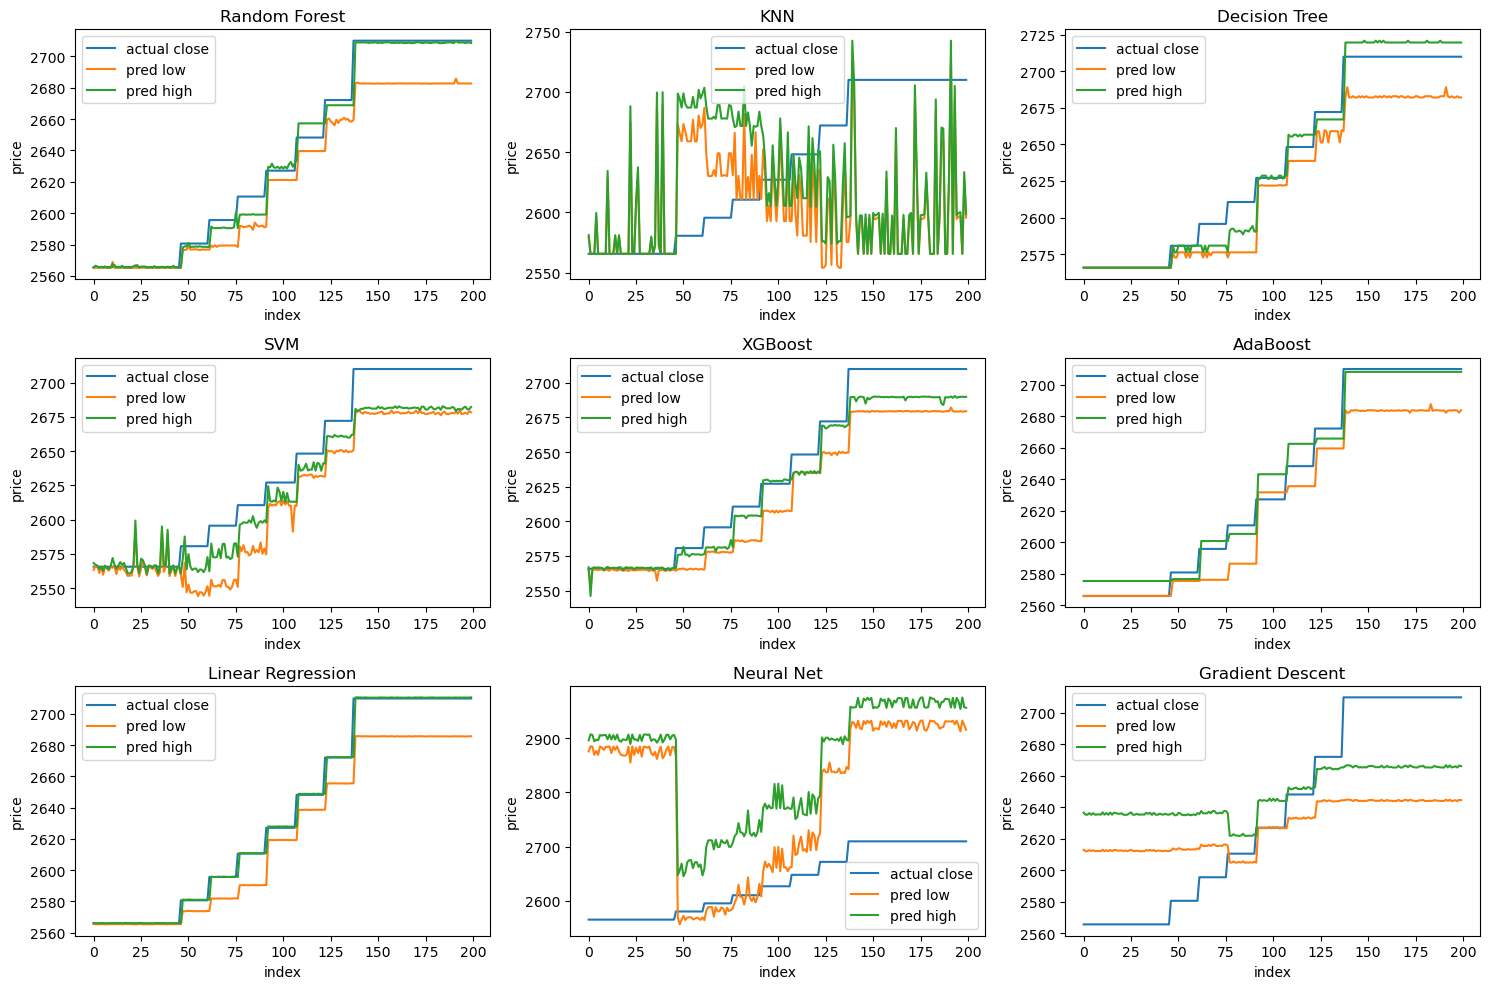

In [14]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

models = {
    "Random Forest": (pred_low_rf, pred_high_rf),
    "KNN": (pred_low_knn, pred_high_knn),
    "Decision Tree": (pred_low_dt, pred_high_dt),
    "SVM": (pred_low_svm, pred_high_svm),
    "XGBoost": (pred_low_xgb, pred_high_xgb),
    "AdaBoost": (pred_low_ada, pred_high_ada),
    "Linear Regression": (pred_low_lr, pred_high_lr),
    "Neural Net": (pred_low_nn, pred_high_nn),
    "Gradient Descent": (pred_low_gd, pred_high_gd)
}

# metric calculation
results = []

for name, (pred_low, pred_high) in models.items():
    low_r2 = r2_score(y_low_test, pred_low)
    high_r2 = r2_score(y_high_test, pred_high)

    mse_low = mean_squared_error(y_low_test, pred_low)
    mse_high = mean_squared_error(y_high_test, pred_high)

    # range accuracy
    correct = ((y_close_test >= pred_low) & (y_close_test <= pred_high)).sum()
    range_acc = (correct / len(y_close_test)) * 100

    results.append({
        "model": name,
        "low_r2": low_r2,
        "high_r2": high_r2,
        "mse_low": mse_low,
        "mse_high": mse_high,
        "range_acc": range_acc
    })

df_results = pd.DataFrame(results)

print("\n===== model comparison =====")
print(df_results.sort_values("range_acc", ascending=False))

# visualization
plt.figure(figsize=(15,10))

for i, (name, (pred_low, pred_high)) in enumerate(models.items(), 1):
    plt.subplot(3,3,i)
    plt.plot(y_close_test[:200], label="actual close")
    plt.plot(pred_low[:200], label="pred low")
    plt.plot(pred_high[:200], label="pred high")
    plt.title(name)
    plt.xlabel("index")
    plt.ylabel("price")
    plt.legend()

plt.tight_layout()
plt.show()